# TESTING - Random search algorithm

In [1]:
METHOD = "RANDOM"

In [2]:
import io
import os
import random
import torch
import json
import contextlib
from ultralytics import YOLO 
from mylib import simsettings
from mylib import myutils
from mylib import simtools
from mylib import yolo_patch_softmax as _
from constants import OBS_SCALE, CELL_SIDE, MAP_RESOLUTION, DISPLAY_STEP
from constants import AGENT_HEIGHT, AGENT_RADIUS 
from constants import MAX_ITER_COEF, CONFIDENCE_THRESHOLD, LOCATION_ERROR_THRESHOLD, PSEUDO_COUNT_THRESHOLD
from constants import ACTIONS   
from constants import NUM_EPOCHS
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils

# Reload imported modules
%load_ext autoreload
%autoreload 2

# Load YOLO model
yolo_model = YOLO("yolo11x.pt")  

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


In [4]:
# Load the JSON file for simulation
with open('simulation-data/simulations.json', 'r') as f:
    simulations = json.load(f)

# Simulation configuration (index selects the simulation)
simulation = simulations[56]

# Access its fields
SCENE = simulation["scene"]
TARGET_OBJECT = simulation["target_object"]
TARGET_OBJECT_ID = simulation["target_object_id"]
REAL_TARGET_LOCATION = simulation["target_object_location"]
INDEX = simulation["index"]

# Load the JSON file for RGB camera intrinsics
with open('simulation-data/camera-intrinsics.json', 'r') as f:
    intrinsics = json.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

In [5]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()

# Define navmesh settings
navmesh_settings = simsettings.create_navmesh_settings(AGENT_HEIGHT, AGENT_RADIUS, max_climb=0.2, max_slope=45.0, include_static_objects=True)

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the top-down map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=MAP_RESOLUTION, draw_border=True)
topdown_map, topdown_resolution = myutils.process_raw_topdown_map(topdown_map)

# Generate the coarse map --> 30 cm per pixel (robot has radius 15 cm)
grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=CELL_SIDE, draw_border=False)
grid_map, grid_resolution = myutils.process_raw_grid_map(grid_map, sim.pathfinder)

# Find free cells in the grid map
grid_free_cells, map_free_cells, world_free_coords = myutils.find_free_cells(grid_map, grid_resolution, topdown_map, topdown_resolution, sim.pathfinder)
num_free_cells = len(grid_free_cells)

In [6]:
starting_grid_positions = []
starting_orientations = []

for _ in range(NUM_EPOCHS):
    # Randomly select a free cell
    starting_grid_positions.append(random.choice(grid_free_cells))
    starting_orientations.append(random.choice([0, 90, 180, 270])) # Random orientation in degrees

# Print it like it was a list
print("starting_grid_positions = [", end="")
for pos in starting_grid_positions:
    print(f"{pos}, ", end="")
print("]")

print("starting_orientations = [", end="")
for ori in starting_orientations:
    print(f"{ori}, ", end="")
print("]")

starting_grid_positions = [[24, 25], [29, 36], [19, 27], [23, 26], [8, 20], [16, 30], [9, 15], [27, 41], [7, 30], [9, 1], [2, 28], [32, 14], [4, 38], [21, 35], [15, 12], [7, 34], [35, 35], [9, 5], [33, 20], [41, 38], [2, 25], [19, 5], [18, 3], [20, 39], [8, 12], [18, 37], [3, 37], [17, 39], [31, 36], [3, 25], [4, 32], [14, 30], [34, 37], [34, 36], [3, 1], [5, 19], [30, 14], [19, 17], [17, 7], [28, 24], [11, 10], [10, 34], [33, 14], [30, 13], [18, 21], [24, 35], [3, 39], [36, 21], [42, 39], [12, 27], [19, 31], [11, 28], [11, 15], [8, 14], [4, 33], [18, 16], [23, 24], [12, 9], [16, 33], [23, 41], [36, 22], [17, 36], [17, 31], [40, 40], [20, 23], [21, 12], [24, 12], [30, 9], [20, 16], [5, 35], [19, 21], [6, 32], [12, 10], [9, 36], [3, 11], [3, 28], [37, 6], [43, 39], [30, 19], [4, 36], [28, 37], [11, 34], [29, 34], [34, 19], [4, 43], [6, 36], [10, 38], [33, 37], [1, 19], [21, 23], [6, 39], [7, 26], [20, 40], [31, 9], [28, 30], [18, 26], [3, 35], [31, 30], [40, 38], [35, 34], ]
starting_or

In [7]:
# Epochs metrics
num_actions_epochs = []
travelled_distance_epochs = []
success_epochs = []
location_error_epochs = []



Simulation 0/100


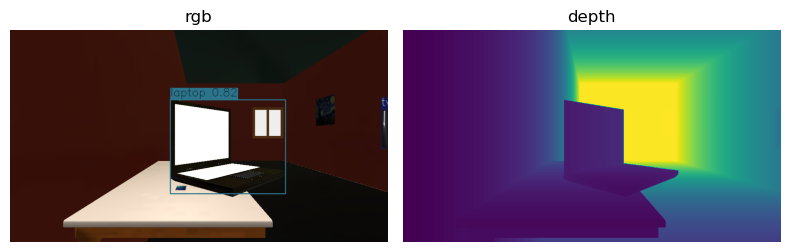

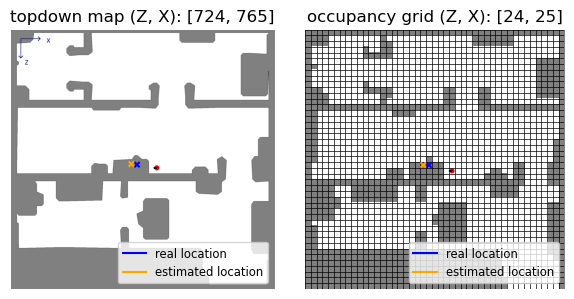


Target object <laptop> found after 3 actions!
Found location: [    -7.3463    0.078657      7.0286]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 3
Travelled distance: 0.00 m
Computed location error: 0.303 m


Simulation 1/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 82.43 m
Computed location error: inf m


Simulation 2/100


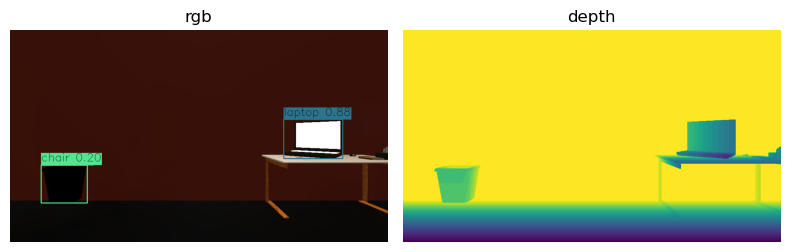

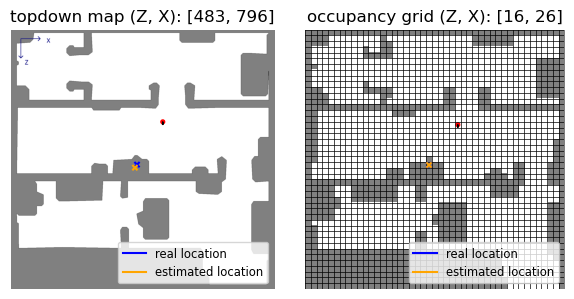


Target object <laptop> found after 70 actions!
Found location: [    -7.1498    0.042294      7.2215]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 70
Travelled distance: 6.08 m
Computed location error: 0.192 m


Simulation 3/100


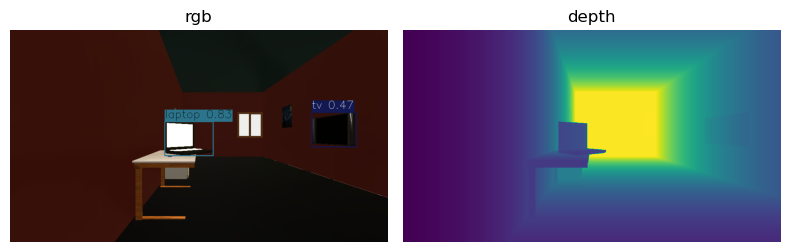

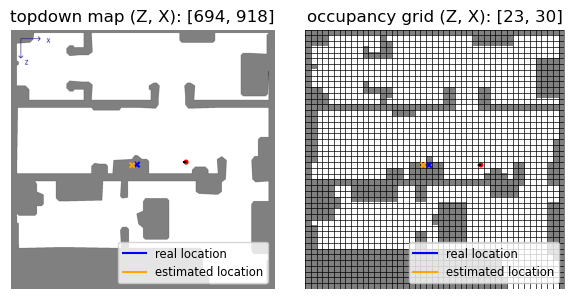


Target object <laptop> found after 19 actions!
Found location: [    -7.2913     0.04404       7.085]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 19
Travelled distance: 2.43 m
Computed location error: 0.247 m


Simulation 4/100


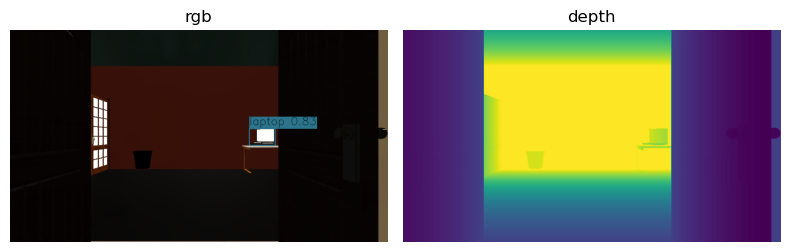

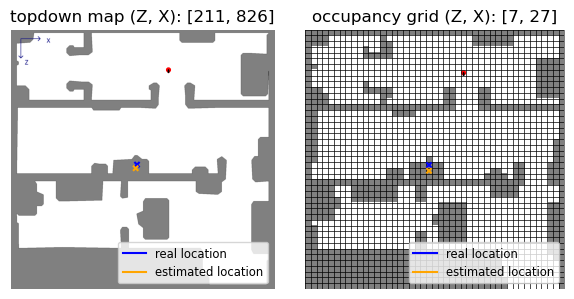


Target object <laptop> found after 42 actions!
Found location: [    -7.1143    0.030226      7.2541]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 42
Travelled distance: 4.87 m
Computed location error: 0.205 m


Simulation 5/100


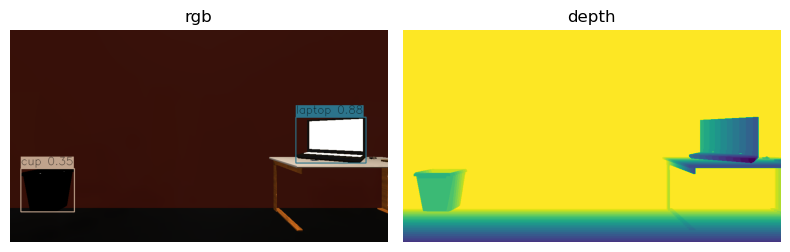

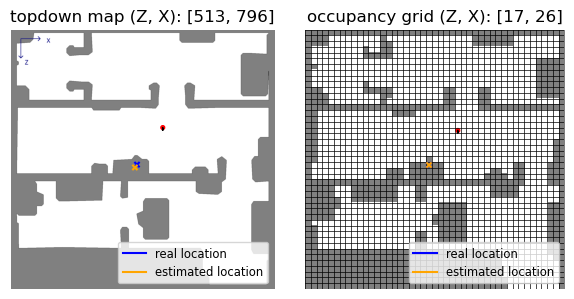


Target object <laptop> found after 32 actions!
Found location: [    -7.1586    0.049108      7.2129]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 32
Travelled distance: 3.98 m
Computed location error: 0.190 m


Simulation 6/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 71.17 m
Computed location error: inf m


Simulation 7/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 75.11 m
Computed location error: inf m


Simulation 8/100


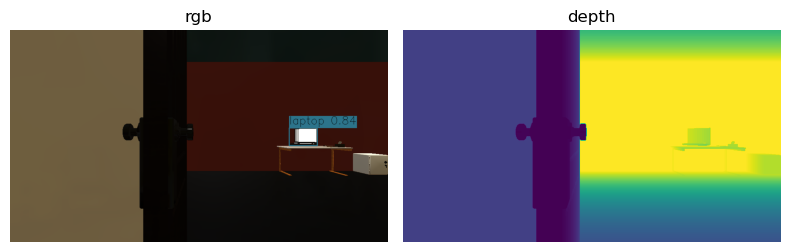

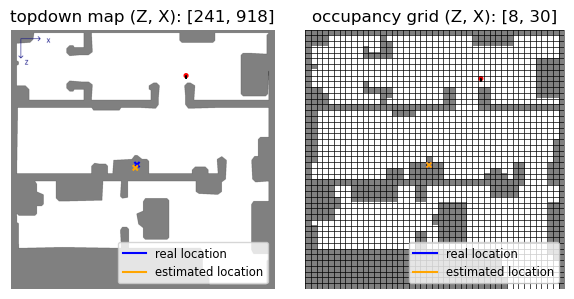


Target object <laptop> found after 1 actions!
Found location: [    -7.1359    0.028332       7.233]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 1
Travelled distance: 0.30 m
Computed location error: 0.195 m


Simulation 9/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 79.40 m
Computed location error: inf m


Simulation 10/100


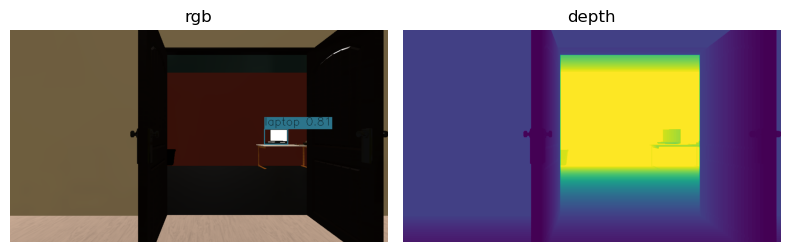

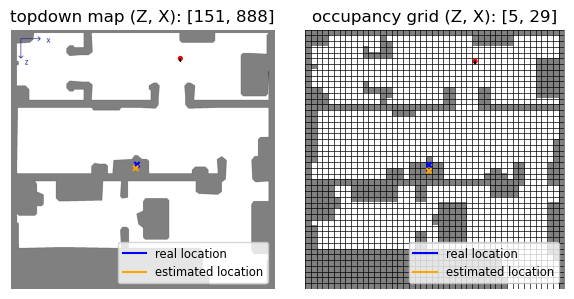


Target object <laptop> found after 226 actions!
Found location: [    -7.1184    0.022494      7.2496]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 226
Travelled distance: 22.51 m
Computed location error: 0.202 m


Simulation 11/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 81.57 m
Computed location error: inf m


Simulation 12/100


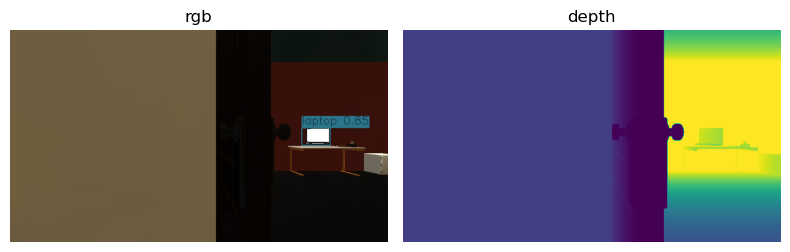

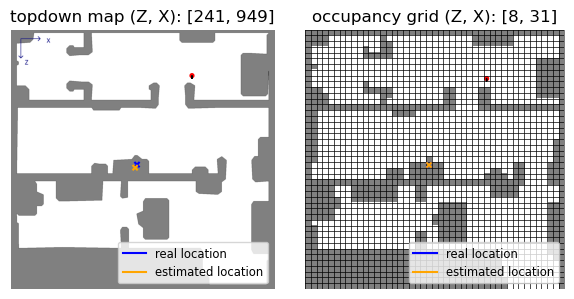


Target object <laptop> found after 115 actions!
Found location: [    -7.1451    0.018852      7.2238]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 115
Travelled distance: 10.01 m
Computed location error: 0.191 m


Simulation 13/100


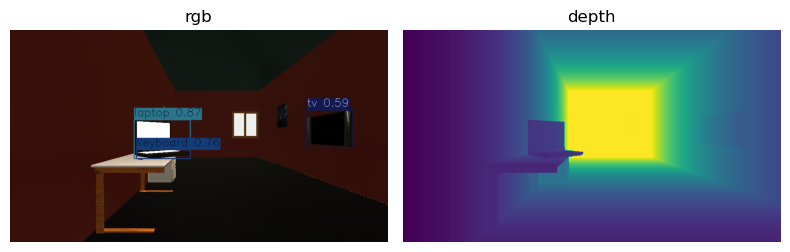

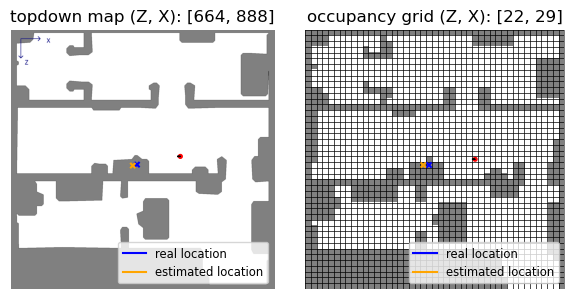


Target object <laptop> found after 476 actions!
Found location: [    -7.2623    0.043652      7.1137]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 476
Travelled distance: 38.66 m
Computed location error: 0.223 m


Simulation 14/100


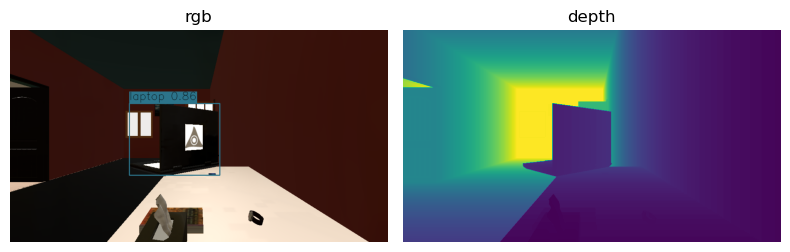

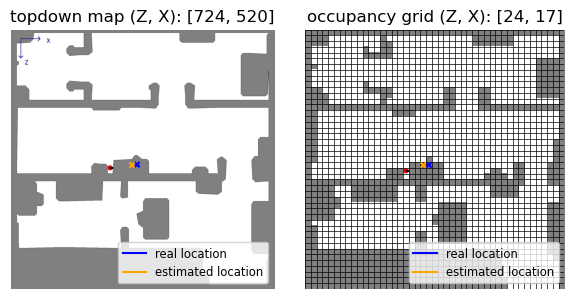


Target object <laptop> found after 103 actions!
Found location: [    -7.3005    0.022526      7.0822]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 103
Travelled distance: 9.72 m
Computed location error: 0.256 m


Simulation 15/100


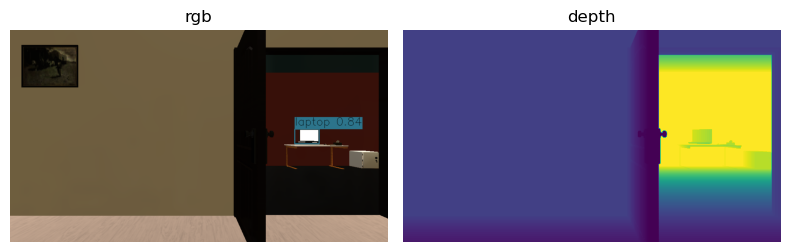

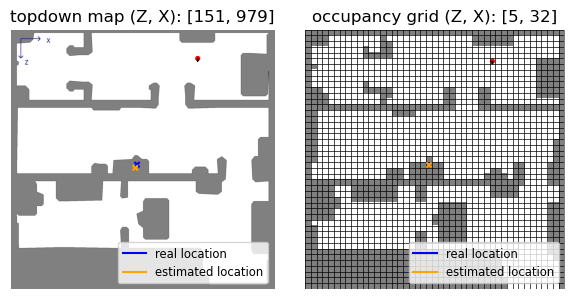


Target object <laptop> found after 420 actions!
Found location: [     -7.135    0.022429       7.233]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 420
Travelled distance: 35.30 m
Computed location error: 0.194 m


Simulation 16/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 80.63 m
Computed location error: inf m


Simulation 17/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 82.20 m
Computed location error: inf m


Simulation 18/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 89.47 m
Computed location error: inf m


Simulation 19/

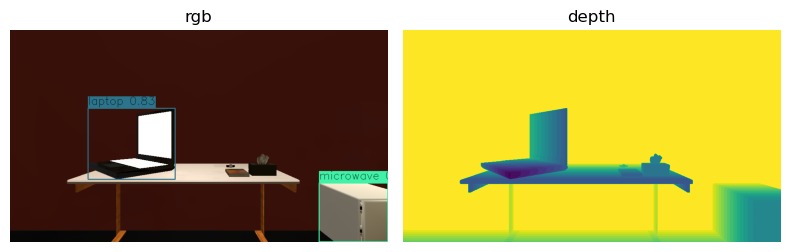

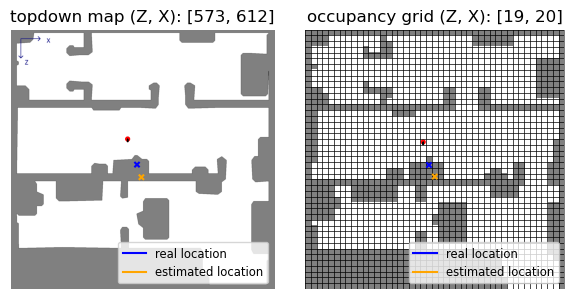


Target object <laptop> not found after 377 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 377
Travelled distance: 37.16 m
Computed location error: 0.701 m


Simulation 23/100


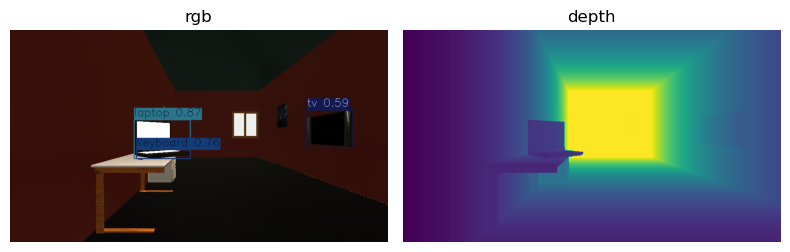

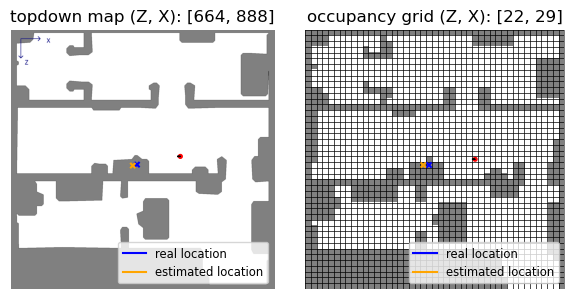


Target object <laptop> found after 726 actions!
Found location: [    -7.2623    0.043652      7.1137]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 726
Travelled distance: 68.77 m
Computed location error: 0.223 m


Simulation 24/100


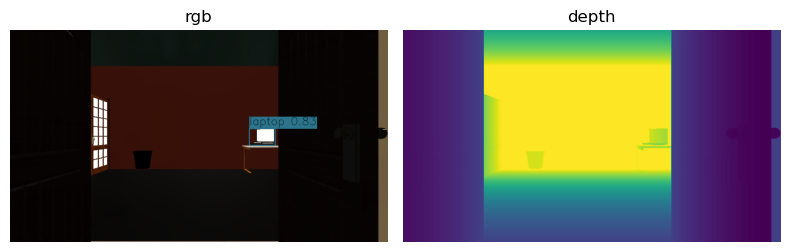

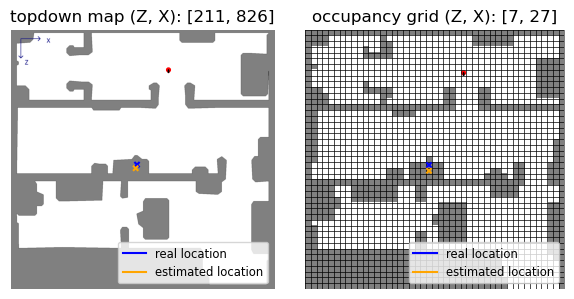


Target object <laptop> found after 316 actions!
Found location: [    -7.1143    0.030226      7.2541]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 316
Travelled distance: 25.56 m
Computed location error: 0.205 m


Simulation 25/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 73.69 m
Computed location error: inf m


Simulation 26/100


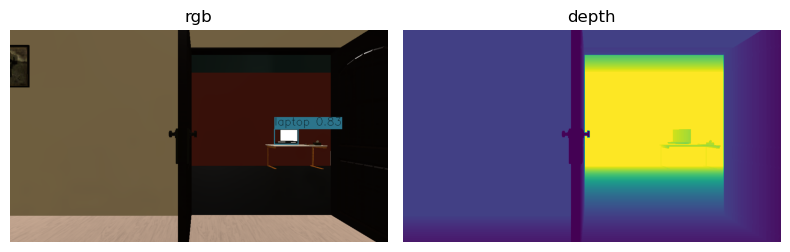

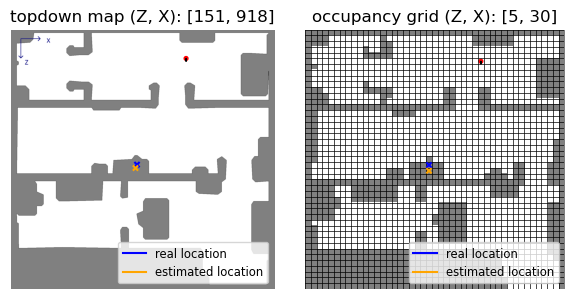


Target object <laptop> found after 238 actions!
Found location: [    -7.1243    0.022471      7.2436]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 238
Travelled distance: 24.08 m
Computed location error: 0.199 m


Simulation 27/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 86.16 m
Computed location error: inf m


Simulation 28/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 90.34 m
Computed location error: inf m


Simulation 29/100


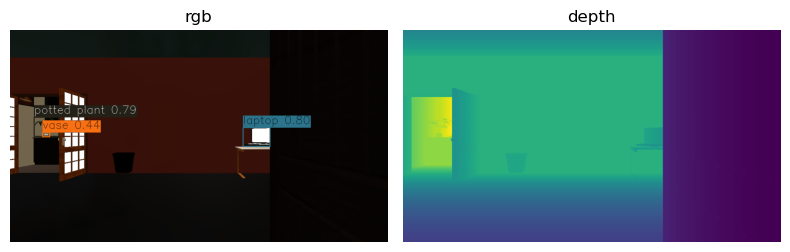

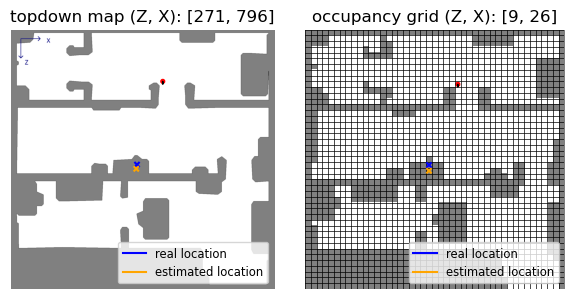


Target object <laptop> found after 194 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 194
Travelled distance: 21.61 m
Computed location error: 0.227 m


Simulation 30/100


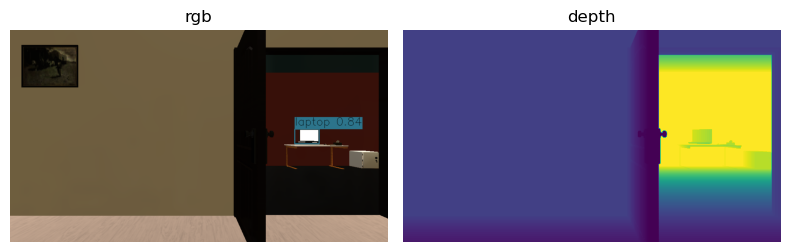

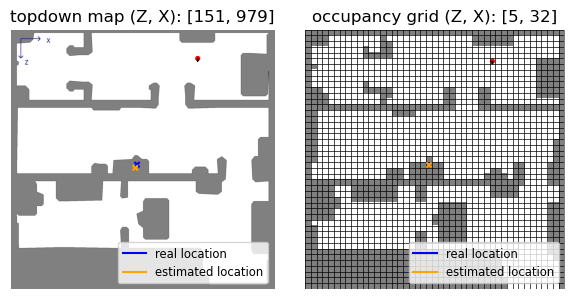


Target object <laptop> found after 5 actions!
Found location: [     -7.135    0.022429       7.233]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 5
Travelled distance: 0.30 m
Computed location error: 0.194 m


Simulation 31/100


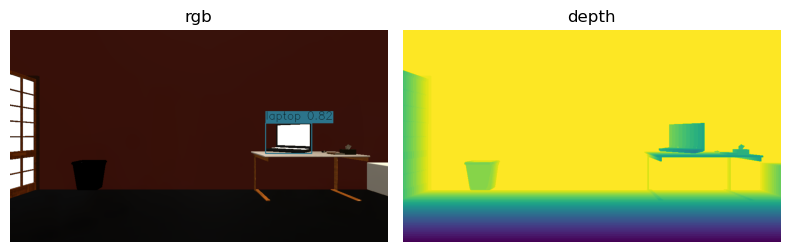

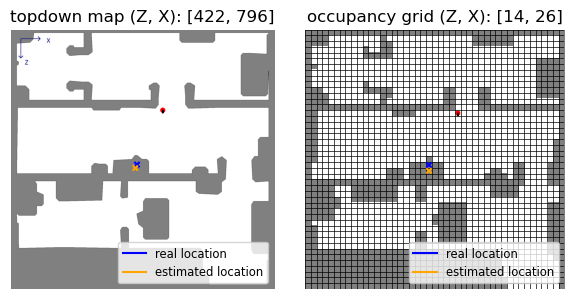


Target object <laptop> found after 35 actions!
Found location: [    -7.1297    0.041423      7.2408]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 35
Travelled distance: 3.67 m
Computed location error: 0.199 m


Simulation 32/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 68.15 m
Computed location error: inf m


Simulation 33/100


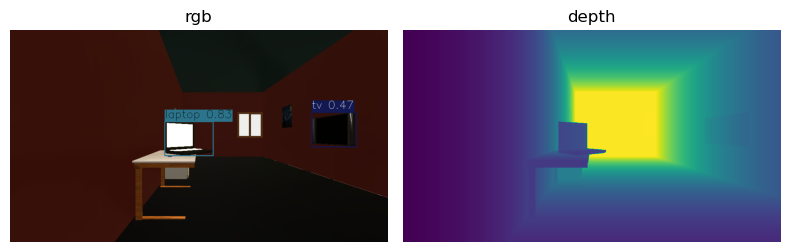

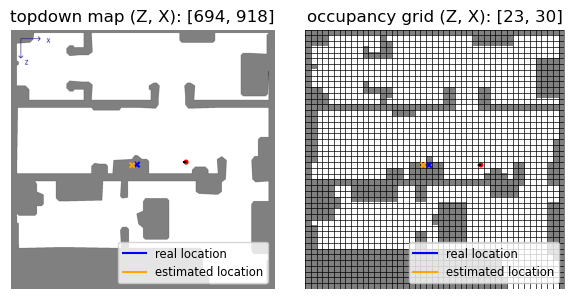


Target object <laptop> found after 787 actions!
Found location: [    -7.2913     0.04404       7.085]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 787
Travelled distance: 64.19 m
Computed location error: 0.247 m


Simulation 34/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 67.80 m
Computed location error: inf m


Simulation 35/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 72.10 m
Computed location error: inf m


Simulation 36/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 86.08 m
Computed location error: inf m


Simulation 37/

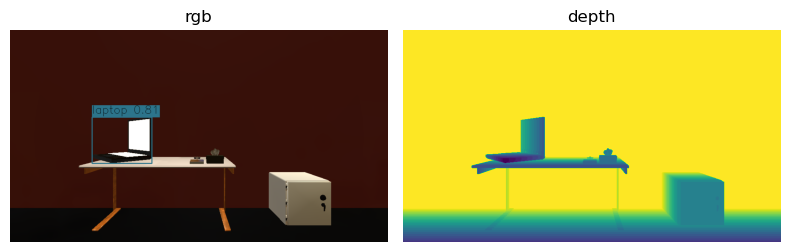

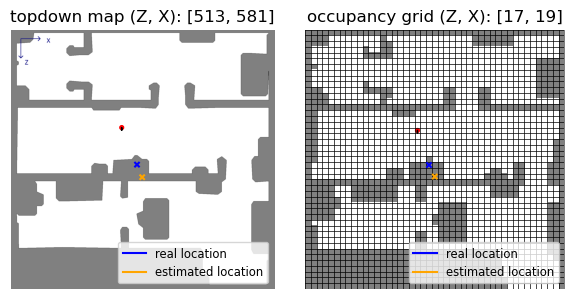


Target object <laptop> not found after 535 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 535
Travelled distance: 52.33 m
Computed location error: 0.716 m


Simulation 39/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 80.95 m
Computed location error: inf m


Simulation 40/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 72.51 m
Computed location error: inf m


Simulation 41/100


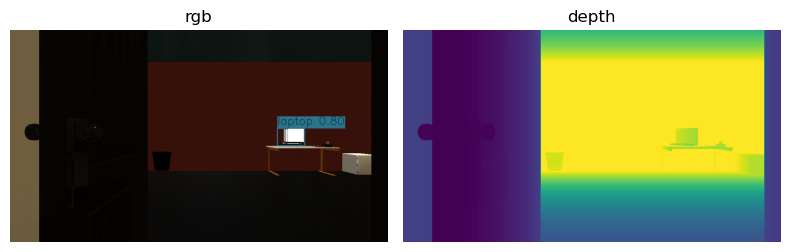

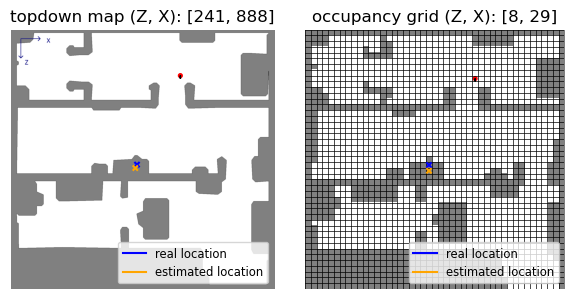


Target object <laptop> found after 334 actions!
Found location: [    -7.1323    0.028353      7.2366]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 334
Travelled distance: 28.90 m
Computed location error: 0.196 m


Simulation 42/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 80.02 m
Computed location error: inf m


Simulation 43/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 80.39 m
Computed location error: inf m


Simulation 44/100

Location error 0.678 m exceeds threshold 0.5 m. FAILURE!


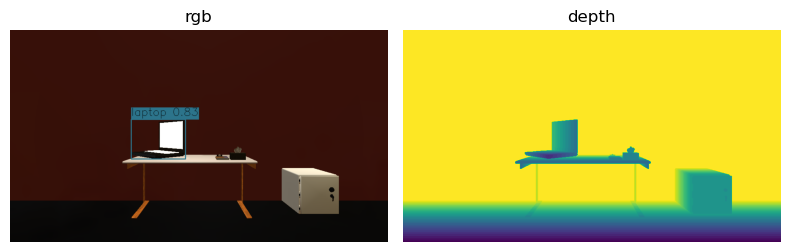

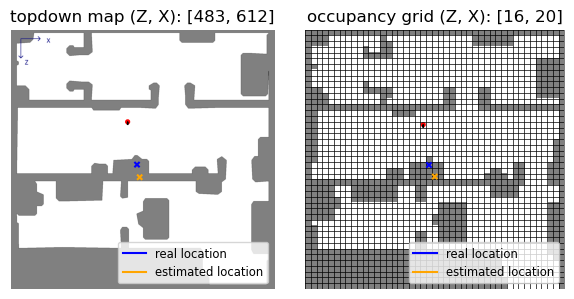


Target object <laptop> not found after 11 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 11
Travelled distance: 0.91 m
Computed location error: 0.678 m


Simulation 45/100


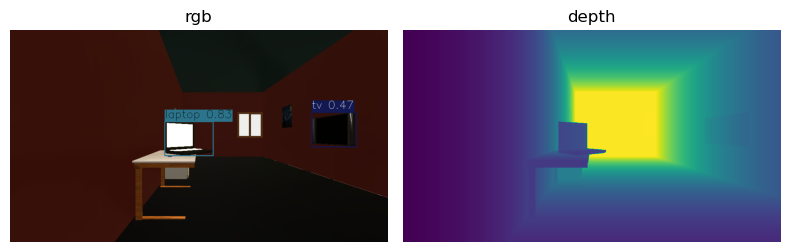

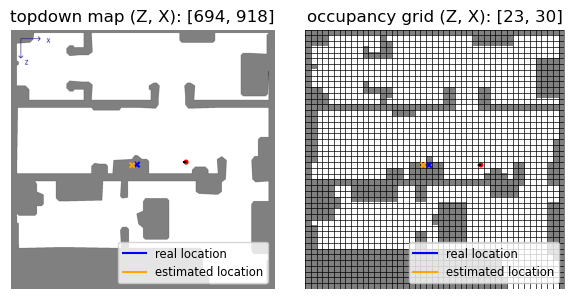


Target object <laptop> found after 724 actions!
Found location: [    -7.2913     0.04404       7.085]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 724
Travelled distance: 54.76 m
Computed location error: 0.247 m


Simulation 46/100


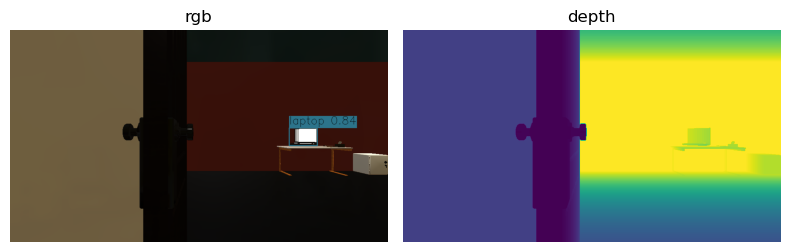

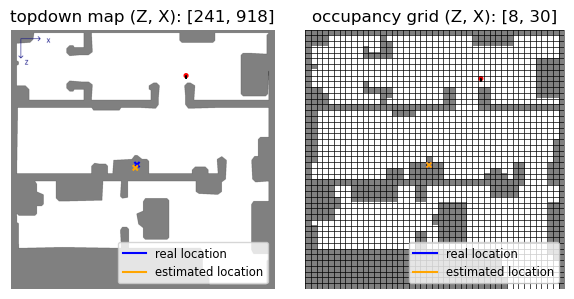


Target object <laptop> found after 727 actions!
Found location: [    -7.1359    0.028332       7.233]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 727
Travelled distance: 62.12 m
Computed location error: 0.195 m


Simulation 47/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 76.67 m
Computed location error: inf m


Simulation 48/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 82.71 m
Computed location error: inf m


Simulation 49/100


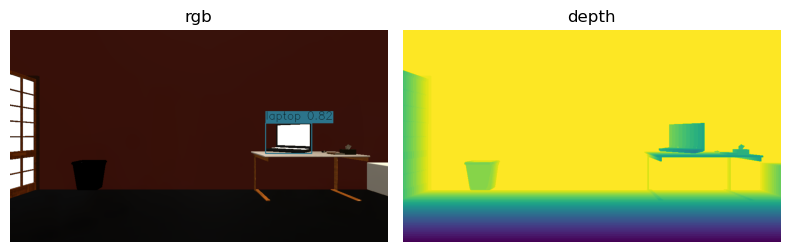

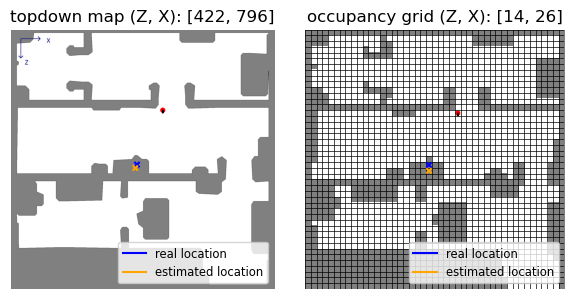


Target object <laptop> found after 15 actions!
Found location: [    -7.1297    0.041423      7.2408]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 15
Travelled distance: 2.12 m
Computed location error: 0.199 m


Simulation 50/100


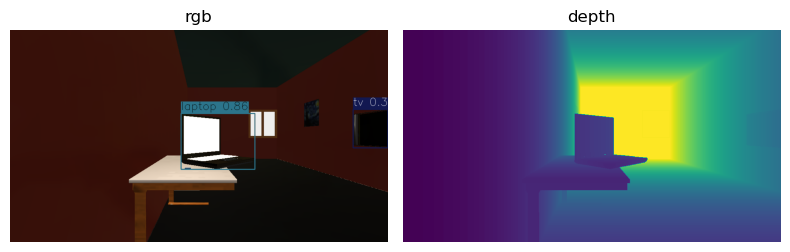

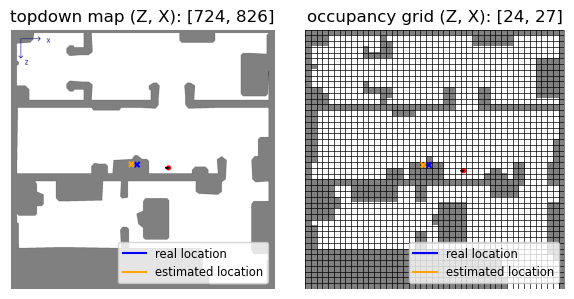


Target object <laptop> found after 386 actions!
Found location: [    -7.3361    0.056973      7.0394]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 386
Travelled distance: 36.78 m
Computed location error: 0.292 m


Simulation 51/100


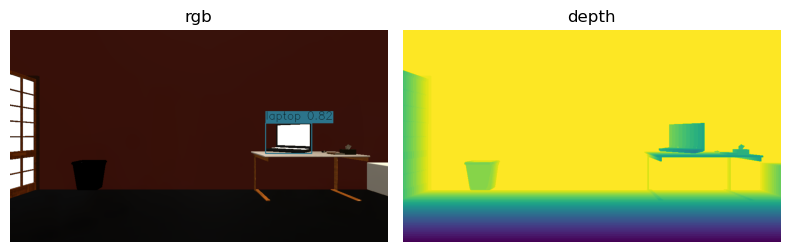

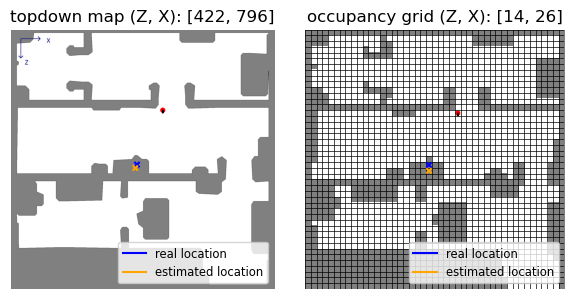


Target object <laptop> found after 70 actions!
Found location: [    -7.1297    0.041423      7.2408]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 70
Travelled distance: 5.78 m
Computed location error: 0.199 m


Simulation 52/100


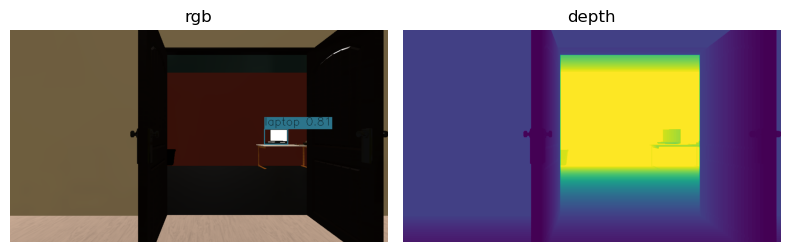

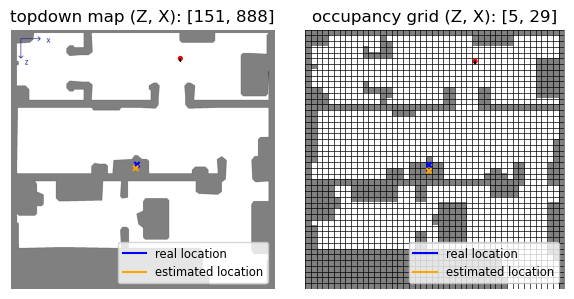


Target object <laptop> found after 246 actions!
Found location: [    -7.1184    0.022494      7.2496]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 246
Travelled distance: 21.28 m
Computed location error: 0.202 m


Simulation 53/100


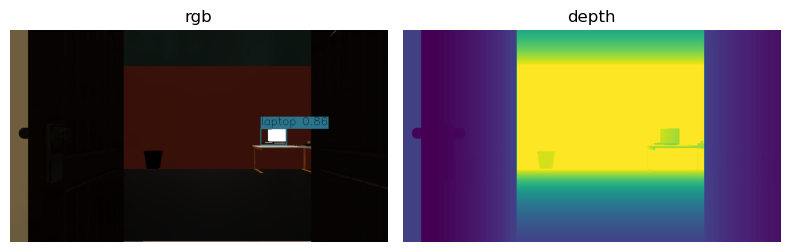

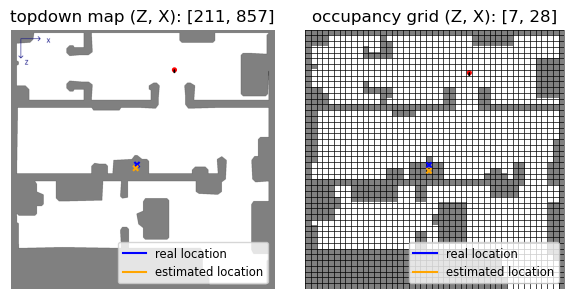


Target object <laptop> found after 214 actions!
Found location: [    -7.1187      0.0302      7.2497]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 214
Travelled distance: 18.57 m
Computed location error: 0.203 m


Simulation 54/100


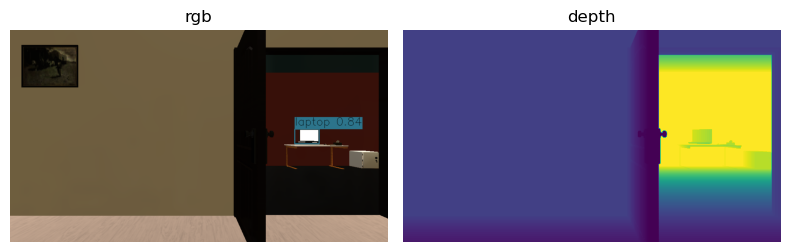

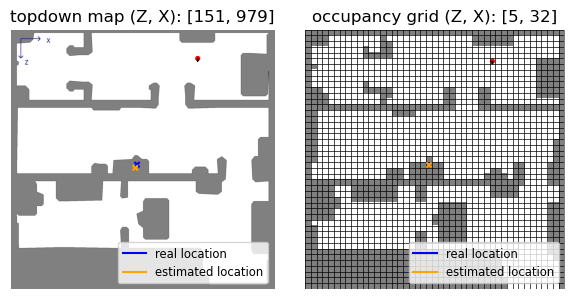


Target object <laptop> found after 7 actions!
Found location: [     -7.135    0.022429       7.233]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 7
Travelled distance: 0.61 m
Computed location error: 0.194 m


Simulation 55/100

Location error 0.678 m exceeds threshold 0.5 m. FAILURE!


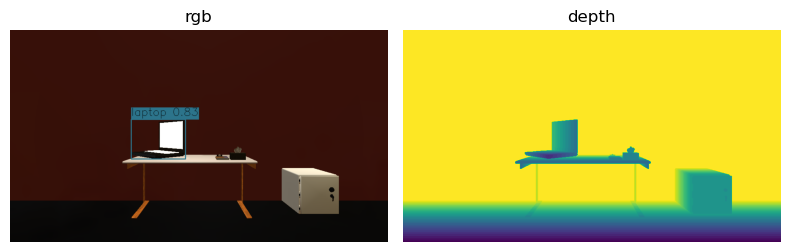

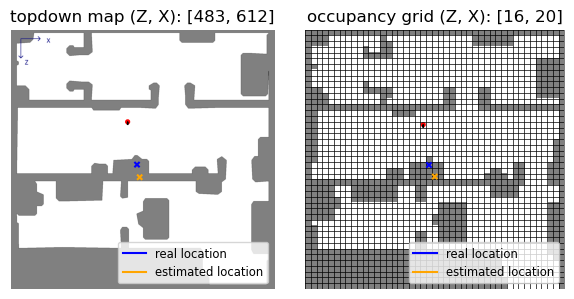


Target object <laptop> not found after 46 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 46
Travelled distance: 4.27 m
Computed location error: 0.678 m


Simulation 56/100


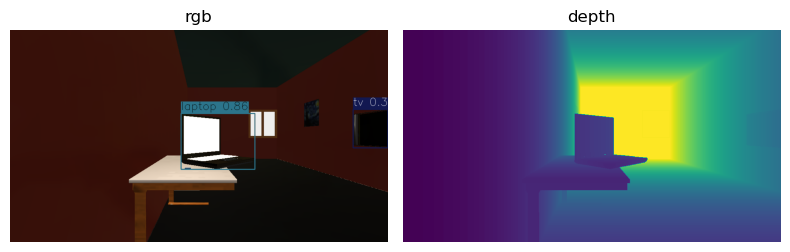

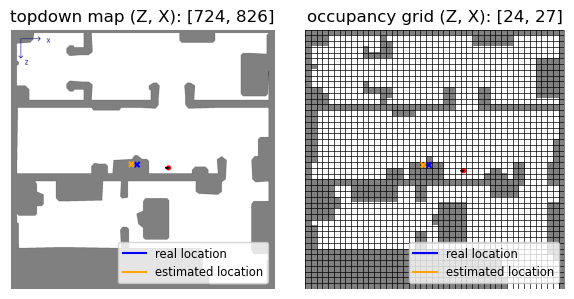


Target object <laptop> found after 13 actions!
Found location: [    -7.3361    0.056973      7.0394]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 13
Travelled distance: 1.83 m
Computed location error: 0.292 m


Simulation 57/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 80.96 m
Computed location error: inf m


Simulation 58/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 84.05 m
Computed location error: inf m


Simulation 59/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 83.33 m
Computed location error: inf m


Simulation 60/100

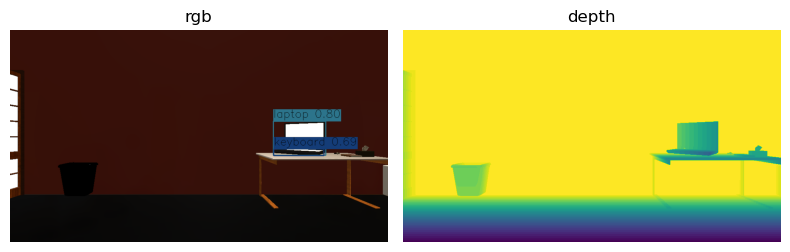

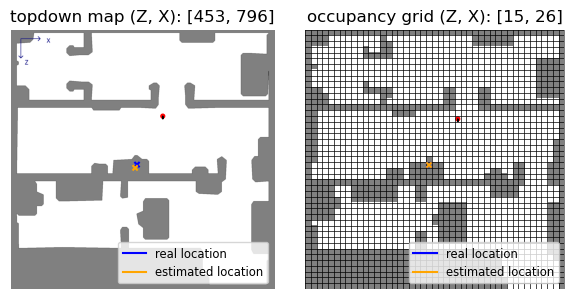


Target object <laptop> found after 227 actions!
Found location: [     -7.141    0.037144        7.23]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 227
Travelled distance: 21.29 m
Computed location error: 0.194 m


Simulation 62/100


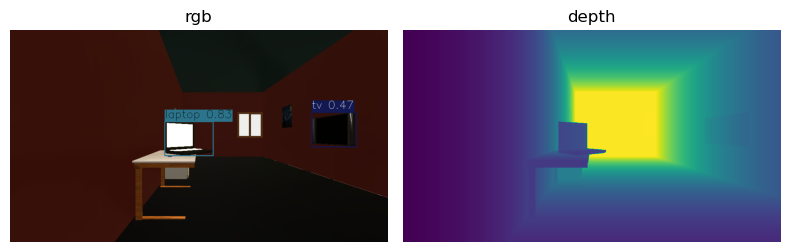

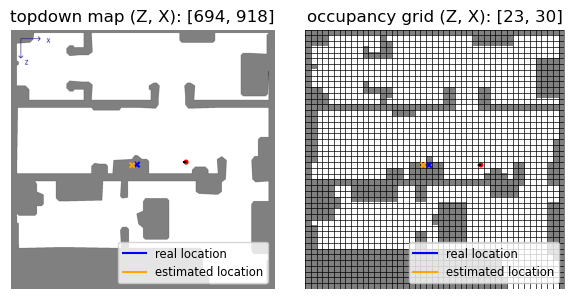


Target object <laptop> found after 57 actions!
Found location: [    -7.2913     0.04404       7.085]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 57
Travelled distance: 4.55 m
Computed location error: 0.247 m


Simulation 63/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 76.69 m
Computed location error: inf m


Simulation 64/100


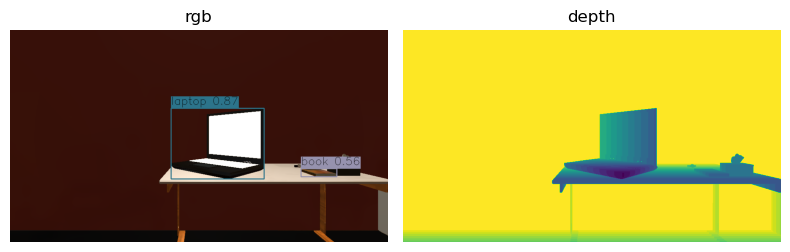

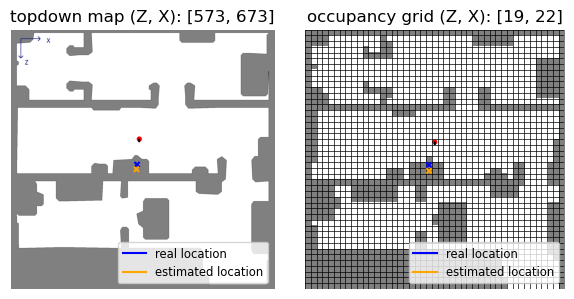


Target object <laptop> found after 8 actions!
Found location: [    -7.0763    0.064547      7.2958]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 8
Travelled distance: 0.61 m
Computed location error: 0.237 m


Simulation 65/100

Location error 0.678 m exceeds threshold 0.5 m. FAILURE!


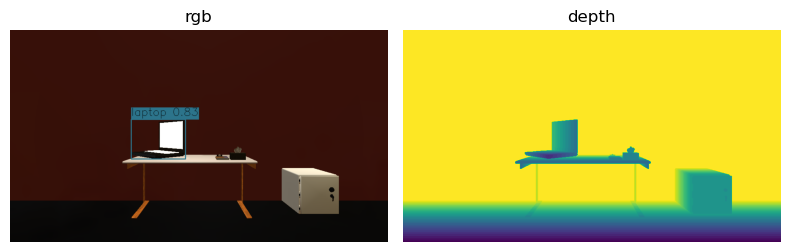

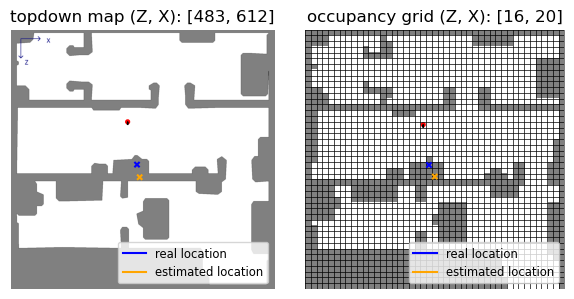


Target object <laptop> not found after 682 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 682
Travelled distance: 57.55 m
Computed location error: 0.678 m


Simulation 66/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 85.56 m
Computed location error: inf m


Simulation 67/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 80.40 m
Computed location error: inf m


Simulation 68/100

Location error 0.678 m exceeds threshold 0.5 m. FAILURE!


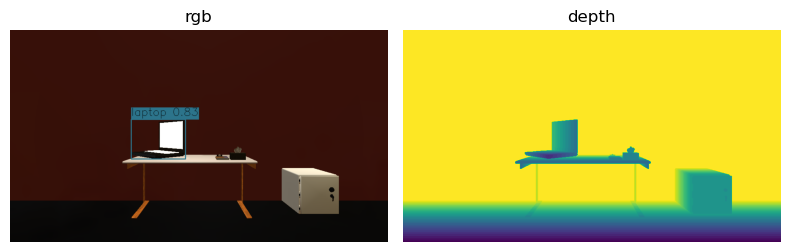

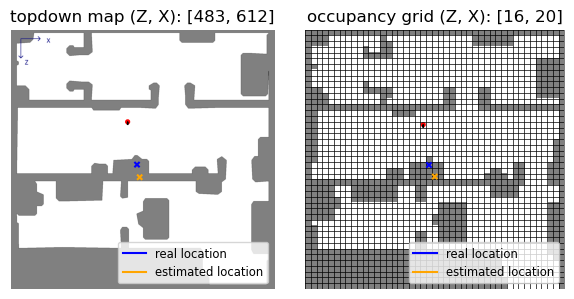


Target object <laptop> not found after 792 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 792
Travelled distance: 69.40 m
Computed location error: 0.678 m


Simulation 69/100


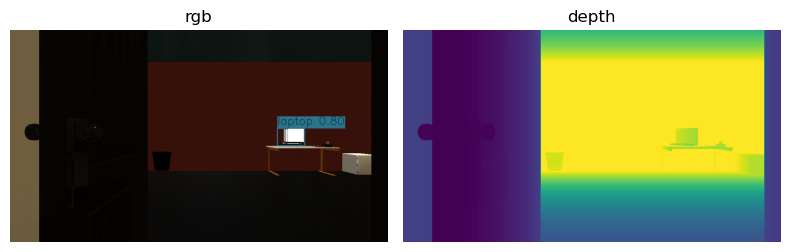

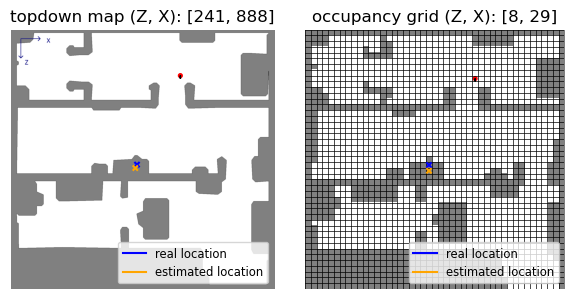


Target object <laptop> found after 896 actions!
Found location: [    -7.1323    0.028353      7.2366]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 896
Travelled distance: 69.08 m
Computed location error: 0.196 m


Simulation 70/100


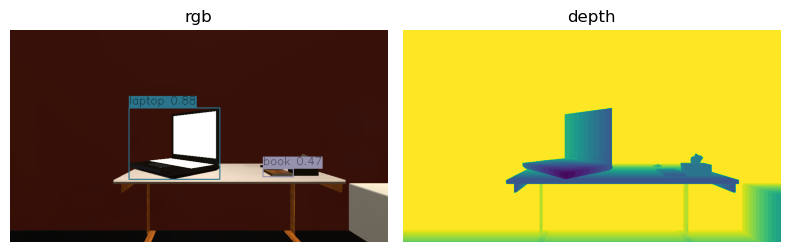

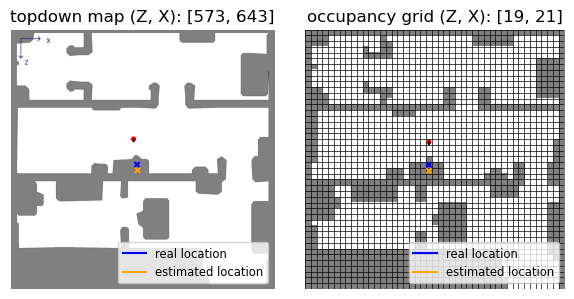


Target object <laptop> found after 1 actions!
Found location: [    -7.0149    0.067063      7.3571]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 1
Travelled distance: 0.00 m
Computed location error: 0.298 m


Simulation 71/100


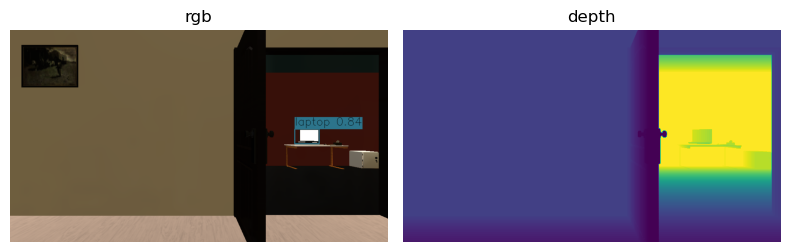

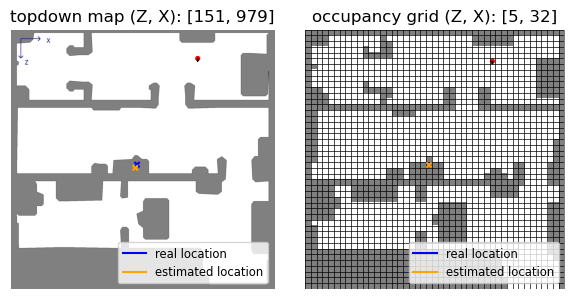


Target object <laptop> found after 12 actions!
Found location: [     -7.135    0.022429       7.233]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 12
Travelled distance: 1.51 m
Computed location error: 0.194 m


Simulation 72/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 69.39 m
Computed location error: inf m


Simulation 73/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 73.36 m
Computed location error: inf m


Simulation 74/100


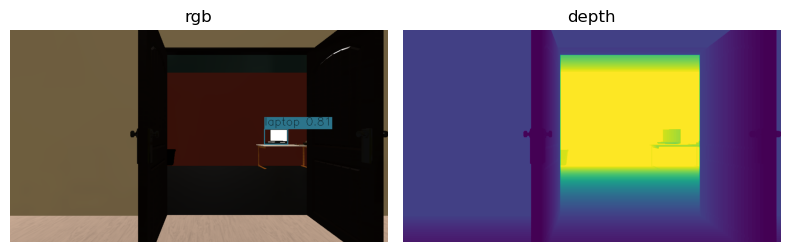

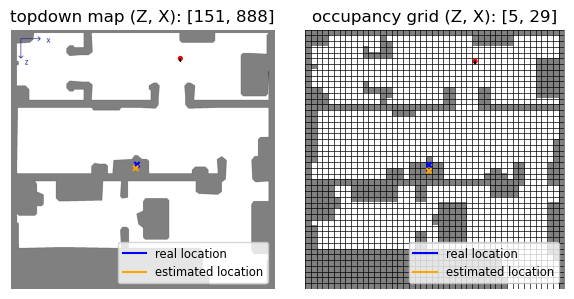


Target object <laptop> found after 256 actions!
Found location: [    -7.1184    0.022494      7.2496]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 256
Travelled distance: 18.28 m
Computed location error: 0.202 m


Simulation 75/100


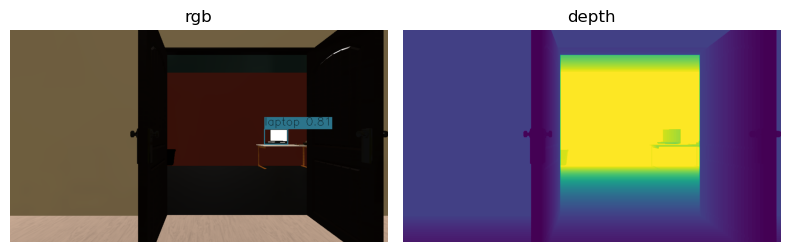

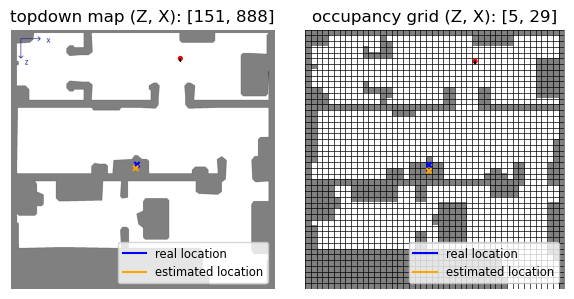


Target object <laptop> found after 11 actions!
Found location: [    -7.1184    0.022494      7.2496]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 11
Travelled distance: 0.91 m
Computed location error: 0.202 m


Simulation 76/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 74.78 m
Computed location error: inf m


Simulation 77/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 81.56 m
Computed location error: inf m


Simulation 78/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 81.55 m
Computed location error: inf m


Simulation 79/100

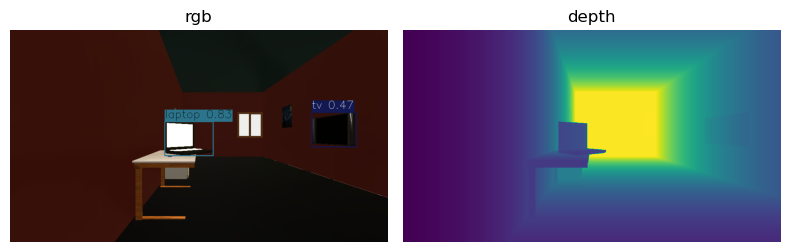

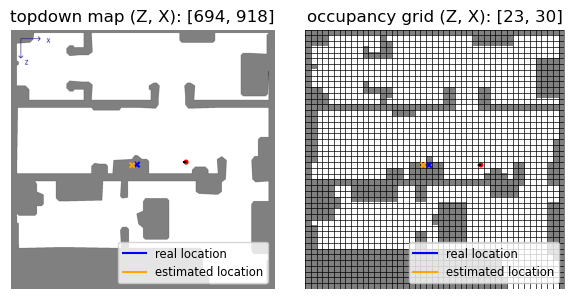


Target object <laptop> found after 926 actions!
Found location: [    -7.2913     0.04404       7.085]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 926
Travelled distance: 74.89 m
Computed location error: 0.247 m


Simulation 81/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 63.95 m
Computed location error: inf m


Simulation 82/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 83.01 m
Computed location error: inf m


Simulation 83/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 80.60 m
Computed location error: inf m


Simulation 84/

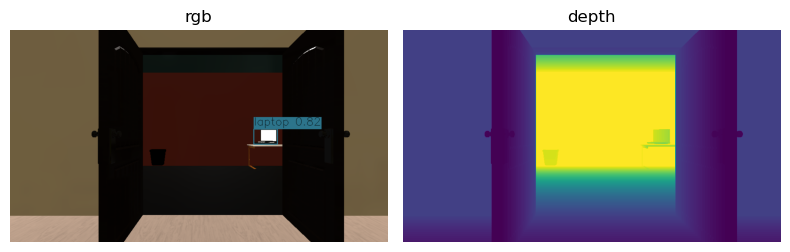

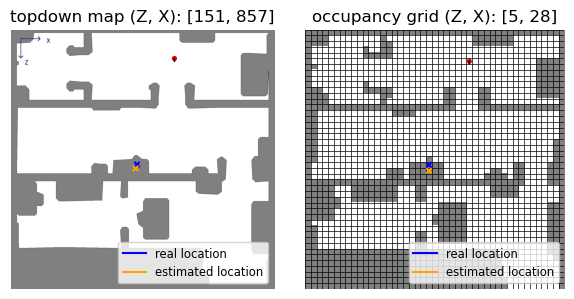


Target object <laptop> found after 698 actions!
Found location: [     -7.112     0.02252      7.2561]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 698
Travelled distance: 56.63 m
Computed location error: 0.206 m


Simulation 85/100


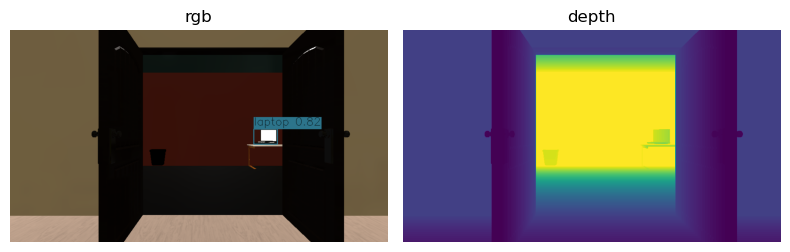

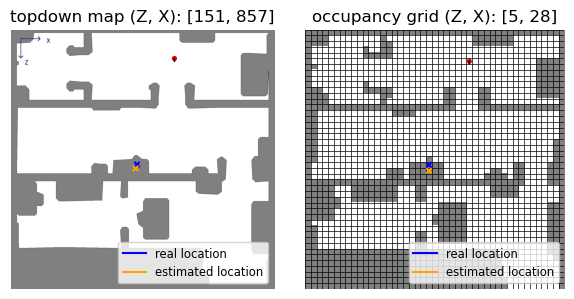


Target object <laptop> found after 78 actions!
Found location: [     -7.112     0.02252      7.2561]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 78
Travelled distance: 8.22 m
Computed location error: 0.206 m


Simulation 86/100


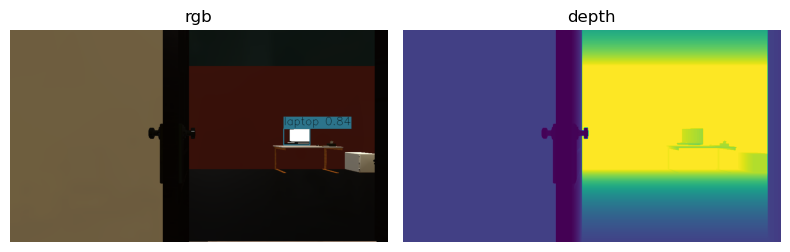

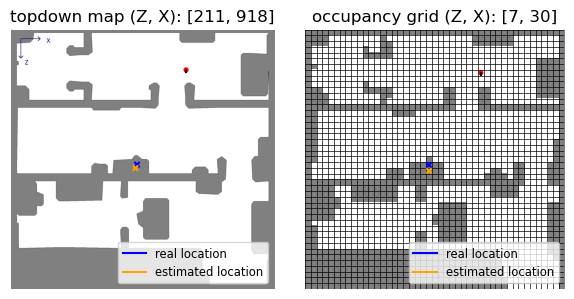


Target object <laptop> found after 104 actions!
Found location: [    -7.1265    0.030156      7.2421]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 104
Travelled distance: 10.63 m
Computed location error: 0.199 m


Simulation 87/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 79.15 m
Computed location error: inf m


Simulation 88/100


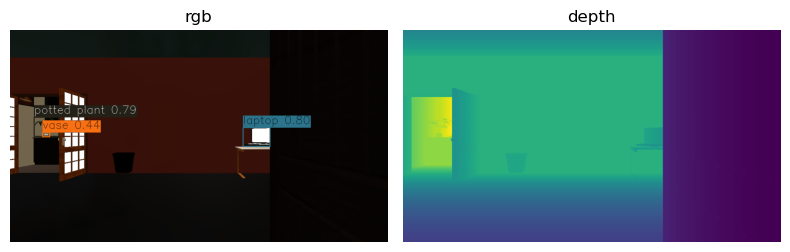

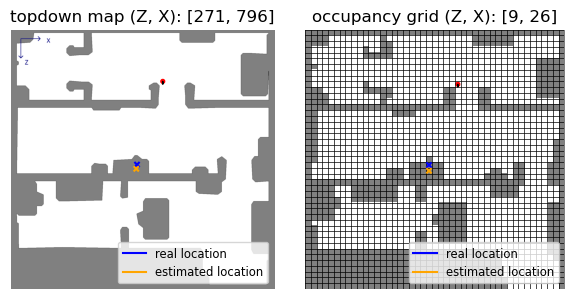


Target object <laptop> found after 334 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 334
Travelled distance: 25.88 m
Computed location error: 0.227 m


Simulation 89/100

Location error 0.678 m exceeds threshold 0.5 m. FAILURE!


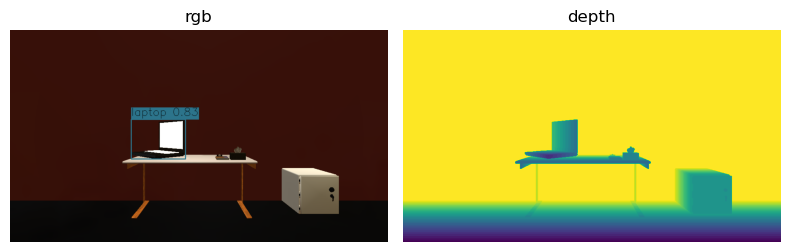

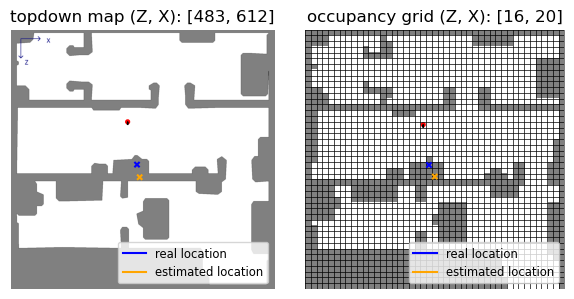


Target object <laptop> not found after 23 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 23
Travelled distance: 3.03 m
Computed location error: 0.678 m


Simulation 90/100


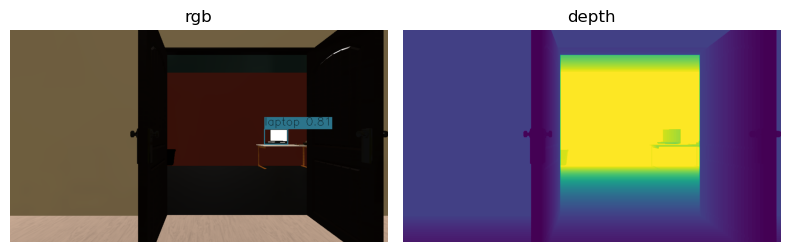

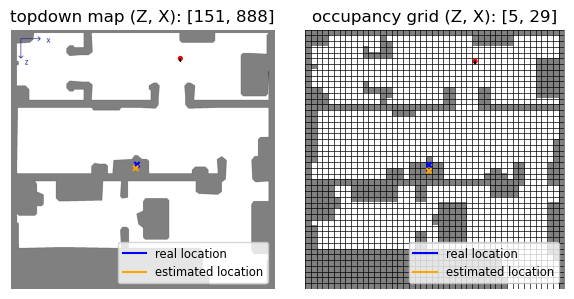


Target object <laptop> found after 289 actions!
Found location: [    -7.1184    0.022494      7.2496]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 289
Travelled distance: 30.75 m
Computed location error: 0.202 m


Simulation 91/100


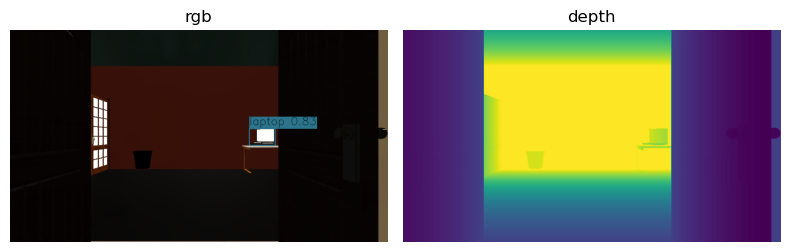

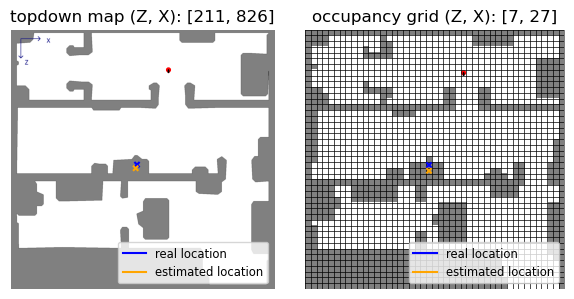


Target object <laptop> found after 58 actions!
Found location: [    -7.1143    0.030226      7.2541]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 58
Travelled distance: 5.80 m
Computed location error: 0.205 m


Simulation 92/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 74.54 m
Computed location error: inf m


Simulation 93/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 73.34 m
Computed location error: inf m


Simulation 94/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 81.83 m
Computed location error: inf m


Simulation 95/100

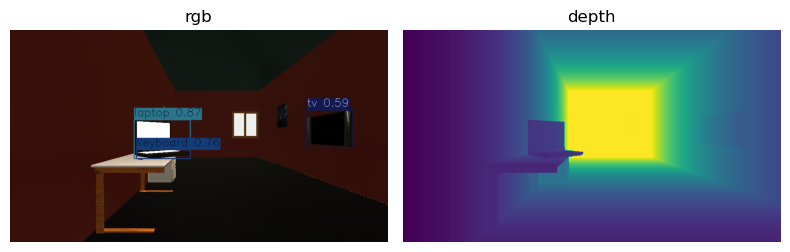

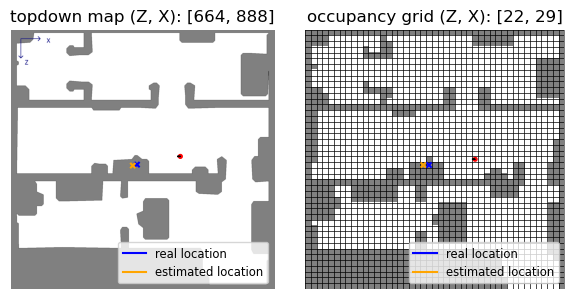


Target object <laptop> found after 40 actions!
Found location: [    -7.2623    0.043652      7.1137]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 40
Travelled distance: 5.18 m
Computed location error: 0.223 m


Simulation 96/100


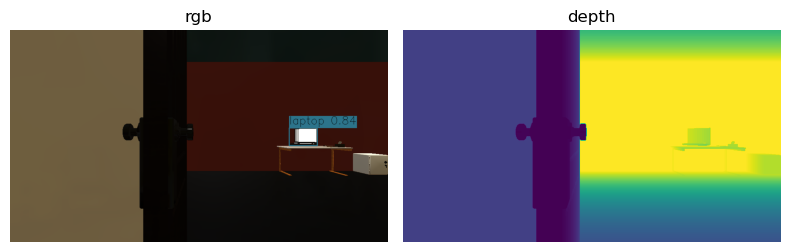

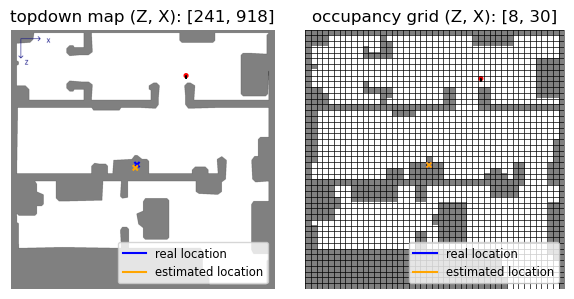


Target object <laptop> found after 128 actions!
Found location: [    -7.1359    0.028332       7.233]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 128
Travelled distance: 9.12 m
Computed location error: 0.195 m


Simulation 97/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 90.99 m
Computed location error: inf m


Simulation 98/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 84.21 m
Computed location error: inf m


Simulation 99/100

Target object <laptop> not found after 950 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 950
Travelled distance: 70.28 m
Computed location error: inf m


In [8]:
for index, (GRID_POSITION, AGENT_YAW) in enumerate(zip(starting_grid_positions, starting_orientations)):

    # Initialize an agent
    agent = sim.initialize_agent(sim_settings["default_agent"])

    # Sample a random position (within the possible ones)
    grid_position = GRID_POSITION
    idx = grid_free_cells.index(grid_position)
    world_position = world_free_coords[idx]
    map_position = map_free_cells[idx]

    # Sample a random yaw rotation
    agent_yaw = AGENT_YAW  # in degrees
    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

    # Set agent state
    agent_state = habitat_sim.AgentState()
    agent_state.position = world_position
    agent_state.rotation = agent_quart
    agent.set_state(agent_state)

    # Compute agent radius in both maps
    min_bounds, max_bounds = sim.pathfinder.get_bounds()
    x_dim = max_bounds[0] - min_bounds[0]
    topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
    grid_radius = (AGENT_RADIUS / x_dim * grid_resolution[0])

    # Get initial agent position tuple and radius tuple
    agent_radius = (topdown_radius, grid_radius)
    agent_positions = (map_position, grid_position)

    # Get initial observations and maps
    observations = sim.get_sensor_observations(0)
    rgb = observations["color_sensor"]
    depth = observations["depth_sensor"]

    # Display the initial simulation state (maps + observations)
    print(f"\n\nSimulation {index}/{len(starting_grid_positions)}")
    #simtools.display_sim_state(rgb, depth, topdown_map, grid_map, agent_positions, agent_radius, agent_yaw)

    # Metrics initialization
    target_found = False
    num_actions = 0
    travelled_distance = 0.0
    location_error = float("inf")

    # Simulation parameters
    MAX_ITER = int(num_free_cells * MAX_ITER_COEF)  # Maximum number of actions to perform

    # Main simulation loop
    while (num_actions < MAX_ITER) and (not target_found):

        # Select an action randomly
        action = random.choice(list(ACTIONS))
        num_actions += 1

        # Check if the action is valid
        if not simtools.is_action_valid(action, grid_position, agent_yaw, grid_free_cells):
            continue 
        
        # Perform the action and update agent state
        grid_position, agent_yaw = simtools.perform_action(action, grid_position, agent_yaw)
        
        # Update the agent position and orientation
        idx = grid_free_cells.index(grid_position)
        map_position, world_position = map_free_cells[idx], world_free_coords[idx]
        agent_quart = myutils.yaw_to_quaternion(agent_yaw)
        agent_positions = (map_position, grid_position)

        # Compute travelled distance
        travelled_distance += simtools.compute_travelled_distance(agent_state.position, world_position)

        # Set agent state
        agent_state.position = world_position
        agent_state.rotation = agent_quart
        agent.set_state(agent_state)

        # Get observations
        obs = sim.get_sensor_observations(0)
        rgb, depth = obs["color_sensor"], obs["depth_sensor"]

        # YOLO Prediction
        results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
        detections = simtools.parse_yolo_detections(results)
        simtools.merge_rgb_yolo_outputs(rgb, detections)
        target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)

    # Compute the target location if it was found
    if target_found:
        # Real world position
        center_x, center_y = simtools.get_box_center(target_bbox)
        depth_value = depth[center_y, center_x]
        target_location = simtools.compute_real_world_position_from_pixel(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, intrinsics)

    # Evaluating correctness of the target detection
    if target_found:
        # Location error
        location_error = simtools.compute_location_error(target_location, REAL_TARGET_LOCATION)

        # Compare with threshold
        if location_error > LOCATION_ERROR_THRESHOLD:
            print(f"\nLocation error {location_error:.3f} m exceeds threshold {LOCATION_ERROR_THRESHOLD} m. FAILURE!")
            target_found = False

        # Plot maps with target
        target_positions = simtools.get_2d_coords(target_location, topdown_resolution, grid_resolution, sim.pathfinder)
        real_target_positions = simtools.get_2d_coords(REAL_TARGET_LOCATION, topdown_resolution, grid_resolution, sim.pathfinder)
        simtools.display_sim_observations(rgb, depth)
        simtools.display_topdown_maps_with_target(topdown_map, grid_map, agent_positions, agent_radius, agent_yaw, target_positions, real_target_positions)

    # Display simulation result and metrics
    if target_found:
        print(f"\nTarget object <{TARGET_OBJECT}> found after {num_actions} actions!")
        print(f"Found location: {target_location}")
    else:
        print(f"\nTarget object <{TARGET_OBJECT}> not found after {num_actions} actions!")

    print(f"Ground-truth location: {REAL_TARGET_LOCATION}")
    print(f"Number of actions: {num_actions}")
    print(f"Travelled distance: {travelled_distance:.2f} m")
    print(f"Computed location error: {location_error:.3f} m")

    # Store metrics
    num_actions_epochs.append(num_actions)
    travelled_distance_epochs.append(travelled_distance)
    success_epochs.append(target_found)
    location_error_epochs.append(location_error)


In [9]:
import numpy as np

# Pre-process
num_actions_epochs = np.array(num_actions_epochs)
travelled_distance_epochs = np.array(travelled_distance_epochs)
success_epochs = np.array(success_epochs)
location_error_epochs = np.array(location_error_epochs)

# Counting
num_total_epochs = len(num_actions_epochs)
num_success_epochs = np.sum(success_epochs)

# Metrics on all runs
total_avg_num_actions = np.sum(num_actions_epochs) / num_total_epochs
total_avg_tavelled_distance = np.sum(travelled_distance_epochs) / num_total_epochs
success_rate = num_success_epochs / num_total_epochs * 100

# Metrics on successful runs
success_avg_travelled_distance = np.sum(travelled_distance_epochs[success_epochs]) / num_success_epochs
success_avg_num_actions = np.sum(num_actions_epochs[success_epochs]) / num_success_epochs
success_avg_location_error = np.sum(location_error_epochs[success_epochs]) / num_success_epochs

#Print final metrics
print("\n\nMETRICS:\n")
print(f"Total number of epochs: {num_total_epochs}")
print(f"Number of successful epochs: {num_success_epochs}")
print(f"Success rate: {success_rate:.2f}%")
print(f"Average number of actions (epochs): {total_avg_num_actions:.2f}")
print(f"Average travelled distance (epochs): {total_avg_tavelled_distance:.2f} m")
print(f"Average success rate (epochs): {success_rate:.2f}%")
print(f"\nAverage number of actions (successful epochs): {success_avg_num_actions:.2f}")
print(f"Average travelled distance (successful epochs): {success_avg_travelled_distance:.2f} m")
print(f"Average location error (successful epochs): {success_avg_location_error:.3f} m")

# Number of actions max, min and std
print(f"\nMax number of actions (epochs): {np.max(num_actions_epochs)}")
print(f"Min number of actions (epochs): {np.min(num_actions_epochs)}")
print(f"Std number of actions (epochs): {np.std(num_actions_epochs)}")    



METRICS:

Total number of epochs: 100
Number of successful epochs: 45
Success rate: 45.00%
Average number of actions (epochs): 587.33
Average travelled distance (epochs): 49.18 m
Average success rate (epochs): 45.00%

Average number of actions (successful epochs): 237.04
Average travelled distance (successful epochs): 20.40 m
Average location error (successful epochs): 0.218 m

Max number of actions (epochs): 950
Min number of actions (epochs): 1
Std number of actions (epochs): 401.2730754735483


In [10]:
metrics_file = 'results/metrics.json'

# Load existing metrics if the file exists, otherwise start with an empty list
if os.path.exists(metrics_file):
    with open(metrics_file, 'r') as f:
        existing_metrics = json.load(f)
else:
    existing_metrics = []

# New metrics entry (convert numpy types to native Python types)
def to_python_type(val):
    if hasattr(val, "item"):
        return val.item()
    return val

new_metrics = {
    "simulation_index": to_python_type(INDEX),
    "scene": SCENE,
    "target_object": TARGET_OBJECT,
    "search_method": METHOD,
    "confidence_threshold": to_python_type(CONFIDENCE_THRESHOLD),
    "max_iter_coefficient": to_python_type(MAX_ITER_COEF),
    "location_error_threshold": to_python_type(LOCATION_ERROR_THRESHOLD),
    "pseudo_count_threshold": to_python_type(PSEUDO_COUNT_THRESHOLD),
    "num_total_epochs": to_python_type(num_total_epochs),
    "num_success_epochs": to_python_type(num_success_epochs),
    "success_rate": to_python_type(success_rate),
    "success_avg_num_actions": to_python_type(success_avg_num_actions),
    "success_avg_travelled_distance": to_python_type(success_avg_travelled_distance),
    "success_avg_location_error": to_python_type(success_avg_location_error),
}

# Check for duplicate (by simulation_index and search_method)
duplicate_exists = any(
    entry["simulation_index"] == new_metrics["simulation_index"] and
    entry["search_method"] == new_metrics["search_method"] 
    for entry in existing_metrics
)

if not duplicate_exists:
    existing_metrics.append(new_metrics)
else:
    print(f"Metrics for simulation_index {new_metrics['simulation_index']} and search_method '{new_metrics['search_method']}' already exist. Skipping append.")

# Save updated metrics list
with open(metrics_file, 'w') as f:
    json.dump(existing_metrics, f, indent=4)

print(f"\nMetrics saved to {metrics_file}")


Metrics saved to results/metrics.json


In [11]:
sim.close()  # Close the simulator